# 라이브러리 세팅

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 데이터 로드

In [2]:
df = pd.read_csv("clustered_data2.csv")

features = [
    'activity_score', 'activity_steps', 'activity_inactive', 'activity_high',
    'activity_score_meet_daily_targets', 'activity_score_move_every_hour',
    'activity_daily_movement', 'activity_total'
]
X = df[features].values.astype(np.float32)
y = df['risk_level'].values.astype(np.int64)

# 데이터 분할

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)

# Tensor 변환 및 DataLoader 생성

In [12]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32) #1트: batch64, 2트: batch32


# MLP 모델 정의

In [13]:
class RiskClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
            )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RiskClassifier().to(device)

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 루프
epochs = 150 #1트: epoch50, 2트: epoch100
train_loss_history, val_loss_history = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_outputs = model(X_val_batch)
            val_loss += criterion(val_outputs, y_val_batch).item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/150 | Train Loss: 0.7958 | Val Loss: 0.6069
Epoch 2/150 | Train Loss: 0.6230 | Val Loss: 0.5176
Epoch 3/150 | Train Loss: 0.5698 | Val Loss: 0.4873
Epoch 4/150 | Train Loss: 0.5351 | Val Loss: 0.4577
Epoch 5/150 | Train Loss: 0.5002 | Val Loss: 0.4423
Epoch 6/150 | Train Loss: 0.4824 | Val Loss: 0.4023
Epoch 7/150 | Train Loss: 0.4739 | Val Loss: 0.3873
Epoch 8/150 | Train Loss: 0.4455 | Val Loss: 0.3723
Epoch 9/150 | Train Loss: 0.4366 | Val Loss: 0.3557
Epoch 10/150 | Train Loss: 0.4271 | Val Loss: 0.3619
Epoch 11/150 | Train Loss: 0.4214 | Val Loss: 0.3480
Epoch 12/150 | Train Loss: 0.4095 | Val Loss: 0.3293
Epoch 13/150 | Train Loss: 0.3966 | Val Loss: 0.3367
Epoch 14/150 | Train Loss: 0.3928 | Val Loss: 0.3272
Epoch 15/150 | Train Loss: 0.3831 | Val Loss: 0.3096
Epoch 16/150 | Train Loss: 0.3799 | Val Loss: 0.3099
Epoch 17/150 | Train Loss: 0.3693 | Val Loss: 0.3092
Epoch 18/150 | Train Loss: 0.3629 | Val Loss: 0.3018
Epoch 19/150 | Train Loss: 0.3566 | Val Loss: 0.2890
Ep

# Loss 그래프

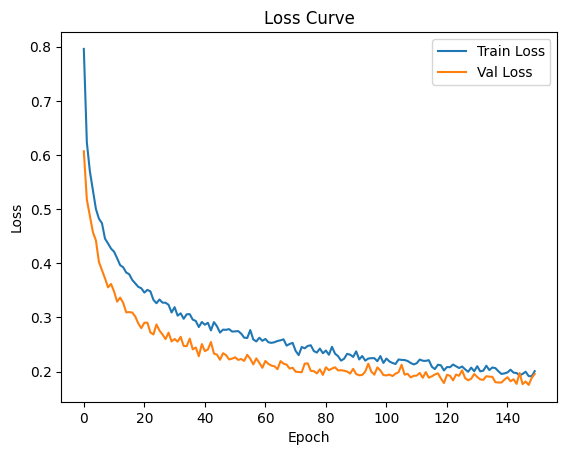

In [14]:
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 테스트 평가

Classification Report:
              precision    recall  f1-score   support

           0     0.5000    0.4000    0.4444         5
           1     0.9309    0.9496    0.9402      1150
           2     0.8673    0.8433    0.8551       651
           3     0.8015    0.7778    0.7895       135

    accuracy                         0.9006      1941
   macro avg     0.7749    0.7427    0.7573      1941
weighted avg     0.8995    0.9006    0.8999      1941



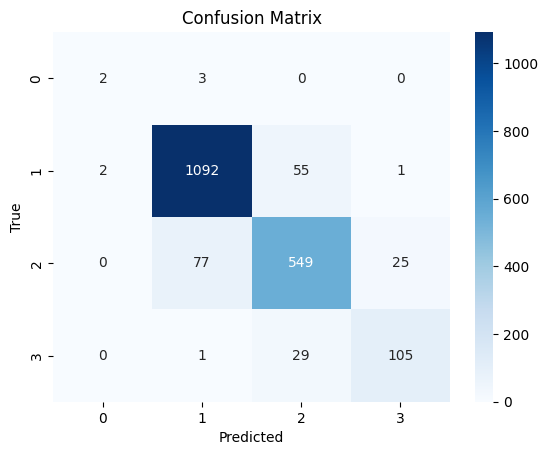

In [15]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()